In [1]:
import numpy as np
import xarray as xr
import xesmf
import sys
import copy
import warnings

import pandas as pd
import os
import tqdm
from scipy.spatial import cKDTree

# warnings.filterwarnings("ignore")


In [2]:
"""
preprocess_glofas_to_dai.py
============================
Converts raw GloFAS v4.0 discharge files into a Dai & Trenberth compatible
station-based NetCDF readable by roms-tools DaiRiverDataset.

Dependencies: numpy, xarray, pandas

Citations:
    GloFAS v4.0: Harrigan S et al. (2020) ESSD doi:10.5194/essd-12-2043-2020
                 Grimaldi S et al. (2022) JRC Technical Report JRC131349
    Dai & Trenberth: Dai A & Trenberth KE (2002) J. Hydrometeorol. 3 660
    outflow point algorithm adapted from:
        Fan (2025, Resplandy Group Princeton) make_runoff_files_glofas_ldd.ipynb
"""

'\npreprocess_glofas_to_dai.py\n============================\nConverts raw GloFAS v4.0 discharge files into a Dai & Trenberth compatible\nstation-based NetCDF readable by roms-tools DaiRiverDataset.\n\nDependencies: numpy, xarray, pandas\n\nCitations:\n    GloFAS v4.0: Harrigan S et al. (2020) ESSD doi:10.5194/essd-12-2043-2020\n                 Grimaldi S et al. (2022) JRC Technical Report JRC131349\n    Dai & Trenberth: Dai A & Trenberth KE (2002) J. Hydrometeorol. 3 660\n    outflow point algorithm adapted from:\n        Fan (2025, Resplandy Group Princeton) make_runoff_files_glofas_ldd.ipynb\n'

In [3]:
DAI_FILE     = "./dai_trenberth_may2019.nc"
GLOFAS_DIR   = "/anvil/projects/x-ees250129/Datasets/Rivers/glofas_data/"
LDD_FILE     = GLOFAS_DIR + "ldd_glofas_v4_0.nc"
UPAREA_FILE = GLOFAS_DIR + "uparea_glofas_v4_0.nc"

OUTPUT_FILE  = "glofas_v4_rivers.nc"

START_YEAR   = 1979    # first year of GloFAS files to process
END_YEAR     = 2024    # last year inclusive

# THRESHOLD_KM = 150.0   # search radius for matching outflow points to Dai river mouths
# MIN_Q        = 0.1    # minimum mean annual discharge (m³/s) — filters tiny drains

MIN_UPAREA = 1  # m² = 10 km² — filters tiny coastal drains

# =============================================================================


EARTH_RADIUS_KM = 6371.0


def haversine_km(lon1, lat1, lon2, lat2):
    """Great circle distance in km. Inputs in degrees. Vectorized."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def make_default_name(lat, lon):
    """Coordinate-based river name for unmatched outflow points."""
    ns = "N" if lat >= 0 else "S"
    ew = "E" if lon >= 0 else "W"
    return f"GloFAS_{abs(lat):.2f}{ns}_{abs(lon):.2f}{ew}"

LDD_DIRECTION = {
    1:(+1,-1), 2:(+1, 0), 3:(+1,+1),
    4:( 0,-1), 5:( 0, 0), 6:( 0,+1),
    7:(-1,-1), 8:(-1, 0), 9:(-1,+1),
}

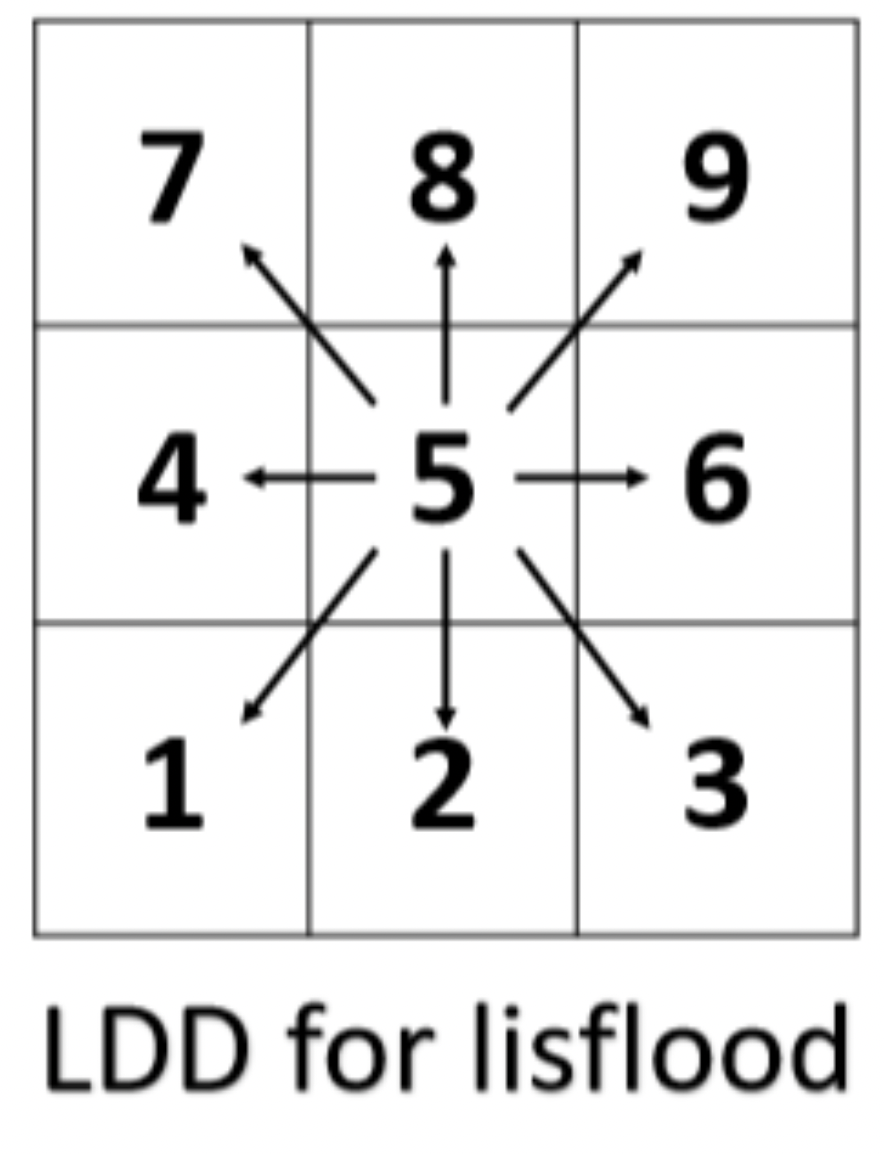


image from https://confluence.ecmwf.int/display/CEMS/Auxiliary+Data

In [4]:
# Load LDD and find outflow points — Fan's iterative approach
## If outflow is on water, turns point into water point and makes adjacent point outflow. 
## iterates until you have an outflow at the water/land interface

print("Loading GloFAS LDD...")
ds_ldd  = xr.open_dataset(LDD_FILE)
ldd_var = next((v for v in ds_ldd.data_vars if 'ldd' in v.lower()), None)
ldd     = ds_ldd[ldd_var].values
lats    = ds_ldd['lat'].values if 'lat' in ds_ldd.coords else ds_ldd['latitude'].values
lons    = ds_ldd['lon'].values if 'lon' in ds_ldd.coords else ds_ldd['longitude'].values
ds_ldd.close()
print(f"LDD: {ldd.shape}")

def update_stencil_sum(ocean_mask):
    """3x3 stencil sum — Fan's exact implementation."""
    stencil = np.zeros(ocean_mask.shape)
    for nlat in range(3):
        ilat_last = -(2 - nlat) if (2 - nlat) != 0 else None
        for nlon in range(3):
            ilon_last = -(2 - nlon) if (2 - nlon) != 0 else None
            stencil[1:-1, 1:-1] += ocean_mask[nlat:ilat_last, nlon:ilon_last]
    return stencil

print("Finding outflow points")
ocean_mask = np.isnan(ldd)
n_updates  = 1
iterations = 0
while n_updates > 0:
    n_updates   = 0
    stencil_sum = update_stencil_sum(ocean_mask)
    for jj in range(len(lats)):
        for ii in range(len(lons)):
            if (ldd[jj,ii]==5) and (not ocean_mask[jj,ii]) and (stencil_sum[jj,ii]>0):
                ocean_mask[jj,ii] = True
                n_updates += 1
    iterations += 1

outflow_mask = (ldd == 5) & (stencil_sum > 0)
j_idx, i_idx = np.where(outflow_mask)
print(f"Found {len(j_idx):,} outflow points after {iterations} iterations")

Loading GloFAS LDD...
LDD: (3000, 7200)
Finding outflow points
Found 141,676 outflow points after 22 iterations


In [5]:
# ── Supplementary pass: catch large-drainage sinks missed by ocean-adjacency filter ──
# Some major river outlets (e.g. Columbia) have no ocean-adjacent LDD cells because
# the estuary is classified as land in GloFAS. Catch them via distance-to-coast.

ds_up   = xr.open_dataset(UPAREA_FILE)
up_var  = next((v for v in ds_up.data_vars if 'uparea' in v.lower() or 'area' in v.lower()), None)
uparea  = ds_up[up_var].values
MIN_UPAREA_SUPPLEMENT = 10_000e6  # 10,000 km² — only large rivers

print("\nSupplementary pass: finding large rivers missed by ocean-adjacency filter...")

# All ldd==5 sinks with large upstream area not already captured
all_sink_j, all_sink_i = np.where((ldd == 5) & ~outflow_mask)
sink_upareas = np.array([uparea[j, i] for j, i in zip(all_sink_j, all_sink_i)])
large_mask = sink_upareas >= MIN_UPAREA_SUPPLEMENT
all_sink_j = all_sink_j[large_mask]
all_sink_i = all_sink_i[large_mask]
print(f"  {len(all_sink_j):,} large sinks not captured by primary method")

# Build cKDTree on ocean cell coordinates

ocean_j, ocean_i = np.where(np.isnan(ldd))
ocean_lats_deg = lats[ocean_j]
ocean_lons_deg = lons[ocean_i]
ocean_coords = np.column_stack([np.radians(ocean_lats_deg), np.radians(ocean_lons_deg)])
tree = cKDTree(ocean_coords)

# Query distance to nearest ocean cell for each large sink
sink_lats_deg = lats[all_sink_j]
sink_lons_deg = lons[all_sink_i]
sink_coords = np.column_stack([np.radians(sink_lats_deg), np.radians(sink_lons_deg)])
dists_chord, _ = tree.query(sink_coords)
dists_km = 2 * 6371.0 * np.arcsin(np.clip(dists_chord / 2, 0, 1))

within_100km = dists_km <= 100.0
supp_j = all_sink_j[within_100km]
supp_i = all_sink_i[within_100km]
print(f"  {len(supp_j):,} large rivers within 100km of coast added")
for k in range(len(supp_j)):
    print(f"    {make_default_name(lats[supp_j[k]], lons[supp_i[k]])}  "
          f"uparea={uparea[supp_j[k], supp_i[k]]/1e6:.0f} km²  "
          f"dist={dists_km[within_100km][k]:.1f} km")

# Merge with primary outflow points
j_idx = np.concatenate([j_idx, supp_j])
i_idx = np.concatenate([i_idx, supp_i])
print(f"Total outflow points after supplement: {len(j_idx):,}")


Supplementary pass: finding large rivers missed by ocean-adjacency filter...
  467 large sinks not captured by primary method
  37 large rivers within 100km of coast added
    GloFAS_72.88N_122.97E  uparea=11853 km²  dist=12.4 km
    GloFAS_71.52N_149.97E  uparea=18889 km²  dist=17.6 km
    GloFAS_70.12N_159.62E  uparea=21347 km²  dist=27.8 km
    GloFAS_68.82N_61.12E  uparea=13640 km²  dist=12.4 km
    GloFAS_66.82N_50.38W  uparea=16564 km²  dist=61.4 km
    GloFAS_66.52N_161.18W  uparea=47565 km²  dist=22.2 km
    GloFAS_64.92N_34.62E  uparea=28481 km²  dist=22.9 km
    GloFAS_60.07N_70.98W  uparea=44125 km²  dist=95.2 km
    GloFAS_53.57N_9.67E  uparea=139524 km²  dist=84.7 km
    GloFAS_53.32N_7.27E  uparea=12080 km²  dist=12.4 km
    GloFAS_52.22N_78.28W  uparea=46248 km²  dist=33.4 km
    GloFAS_49.22N_68.38W  uparea=46126 km²  dist=22.2 km
    GloFAS_46.57N_32.42E  uparea=511338 km²  dist=17.6 km
    GloFAS_46.17N_123.28W  uparea=651917 km²  dist=39.3 km
    GloFAS_38.67N_9.12W

In [6]:
# Load upstream area and filter outflow points

print("\nLoading upstream area...")

up_lats = ds_up['latitude'].values if 'latitude' in ds_up.coords else ds_up['lat'].values
up_lons = ds_up['longitude'].values if 'longitude' in ds_up.coords else ds_up['lon'].values
ds_up.close()
print(f"Upstream area: {uparea.shape}  max={np.nanmax(uparea)/1e6:.0f} km²")

# Get upstream area at each outflow point
uparea_at_outflows = np.array([
    uparea[j_idx[k], i_idx[k]]
    if not np.isnan(uparea[j_idx[k], i_idx[k]]) else 0.0
    for k in range(len(j_idx))
])

# Filter by minimum upstream area, currently no filter
keep_mask    = uparea_at_outflows >= MIN_UPAREA
outflow_lats = lats[j_idx][keep_mask]
outflow_lons = lons[i_idx][keep_mask]
uparea_out   = uparea_at_outflows[keep_mask]

print(f"After MIN_UPAREA={MIN_UPAREA/1e6:.0f} km² filter: "
      f"{len(outflow_lats):,} outflow points")

# Auto-name all outflow points by coordinates
names = np.array([make_default_name(lat, lon)
                  for lat, lon in zip(outflow_lats, outflow_lons)])


Loading upstream area...
Upstream area: (3000, 7200)  max=5907195 km²
After MIN_UPAREA=0 km² filter: 141,713 outflow points


In [7]:
jj = np.array([np.argmin(np.abs(lats - lat)) for lat in outflow_lats])
ii = np.array([np.argmin(np.abs(lons - lon)) for lon in outflow_lons])

times_list = []
flow_list  = []

for yr in range(START_YEAR, END_YEAR + 1):
    fpath = os.path.join(GLOFAS_DIR, f"glofas_v4_discharge_{yr}.nc")

    ds = xr.open_dataset(fpath)
    if 'latitude' in ds.dims: ds = ds.rename({'latitude':'lat','longitude':'lon'})
    if 'valid_time' in ds.dims: ds = ds.rename({'valid_time':'time'})

    # Read entire year into memory at once — avoids per-timestep disk reads
    dis_np = ds['dis24'].values          # (n_days, lat, lon)
    t_vals = ds['time'].values           # (n_days,)
    ds.close()

    # Extract all outflow points for all days at once
    flow_yr = np.maximum(dis_np[:, jj, ii], 0.0)  # (n_days, n_stations)

    times_list.append(t_vals)
    flow_list.append(flow_yr)

    if yr % 5 == 0:
        print(f"  {yr}")

times = np.concatenate(times_list)                 # (n_days_total,)
flow  = np.concatenate(flow_list, axis=0)          # (n_days_total, n_stations)
print(f"Output: {len(times)} days x {flow.shape[1]:,} stations")

  1980
  1985
  1990
  1995
  2000
  2005
  2010
  2015
  2020
Output: 16802 days x 141,713 stations


In [8]:
#### Write Dai-compatible NetCDF

print(f"\nWriting {OUTPUT_FILE}...")

ds_out = xr.Dataset({
    'lat_mou':   ('station', outflow_lats.astype('f4')),
    'lon_mou':   ('station', outflow_lons.astype('f4')),
    'FLOW':      (['time', 'station'], flow.astype('f4')),
    'ratio_m2s': ('station', np.ones(len(outflow_lats), dtype='f4')),
    'vol_stn':   ('station', uparea_out.astype('f4')),
    'riv_name':  ('station', names),
    'time':      ('time', times),  # native datetime64 — CF compliant
})

encoding = {
    'FLOW': {'zlib': True, 'complevel': 4, 'dtype': 'float32'},
    'time': {'units': 'days since 1979-01-01', 'calendar': 'gregorian'},
}

ds_out['lat_mou'].attrs   = {'units': 'degrees_north',
                              'long_name': 'river mouth latitude'}
ds_out['lon_mou'].attrs   = {'units': 'degrees_east',
                              'long_name': 'river mouth longitude'}
ds_out['FLOW'].attrs      = {'units': 'm3 s-1',
                              'long_name': 'river discharge',
                              'missing_value': 1e+20}
ds_out['ratio_m2s'].attrs = {'units': '1',
                              'long_name': 'spatial ratio (set to 1.0)'}
ds_out['vol_stn'].attrs   = {'units': 'm2',
                              'long_name': 'upstream drainage area',
                              'comment': 'used for sorting rivers by size'}
ds_out['time'].attrs      = {'long_name':
                              'time '}
ds_out.attrs = {
    'title':  'GloFAS v4.0 river discharge in Dai & Trenberth station format',
    'source': ('GloFAS v4.0: Harrigan S et al. (2020) ESSD '
               'doi:10.5194/essd-12-2043-2020; '
               'Grimaldi S et al. (2022) JRC Technical Report JRC131349.'),
    'method': ('Outflow points identified using iterative ocean mask '
               'expansion from GloFAS LDD (ldd==5, adjacent to ocean NaN); Following method from Fan Yang'
               f'Min upstream area: {MIN_UPAREA/1e6:.0f} km². '
               'All stations auto-named by coordinates GloFAS_LAT_LON. '
               'vol_stn = upstream drainage area (m²) used for sorting.'),
}

OUTPUT_FILE = '/anvil/projects/x-ees250129/Datasets/Rivers/glofas_v4_rivers_daily.nc'

ds_out.to_netcdf(OUTPUT_FILE)
print(f"Done. {len(outflow_lats):,} stations -> {OUTPUT_FILE}")
print(f'\nUsage in roms-tools:')
print(f'  source = {{"name": "DAI", "path": "{OUTPUT_FILE}"}}')


Writing glofas_v4_rivers.nc...
Done. 141,713 stations -> /anvil/projects/x-ees250129/Datasets/Rivers/glofas_v4_rivers_daily.nc

Usage in roms-tools:
  source = {"name": "DAI", "path": "/anvil/projects/x-ees250129/Datasets/Rivers/glofas_v4_rivers_daily.nc"}


In [9]:
# rm glofas_v4_rivers_daily.nc